In [2]:
%load_ext autoreload
%autoreload 2
import sys,os
sys.path.append('../')   
import numpy as np
from model.exactPreference import  exactPreference
from model.LuceJND import  LuceJND
from model.erroneousPreference import  erroneousPreference
from model.gaussianNoisePreferenceFull import  gaussianNoisePreference
from kernel import RBF
from kernel.jaxrbf import RBF as JRBF
from utility import  paramz
# for plotting
import matplotlib.pyplot as plt
import arviz as az

# Thermal comfort

To introduce the concepts, we make use of a simple  running example: learning Alice's  preferred home temperature.
We present Alice with pairs of temperatures (in Celsius) and ask her preferred value. Imagine Alice's utility is as depicted in the below figure.
In order to infer her utility function, we consider the set of temperatures (objects) $\mathcal{X}=\{10,11,12,\dots,25\}$ and asks her preferences for $19$ pairs of temperatures. This results in the dataset: 

\begin{align}
\nonumber
\mathcal{D}_{19}=&\{12\succ 10,13\succ 25,14\succ 13,15\succ 22,15\succ 23,16\succ 11,19\succ 15,19\succ 21,19\succ 22,\\ 
&19\succ 24,20\succ 10,20\succ 14,20\succ 21,20\succ 24,20\succ 25,21\succ 13,21\succ 25,23\succ 25,24\succ 25\}.
\end{align}

We aim to learn Alice's utility function for home-temperature from $\mathcal{D}_{19}$ and predict her preferences for any other pairs of temperatures.

## Alice's true utility function

We assume Alice's true utility function is 

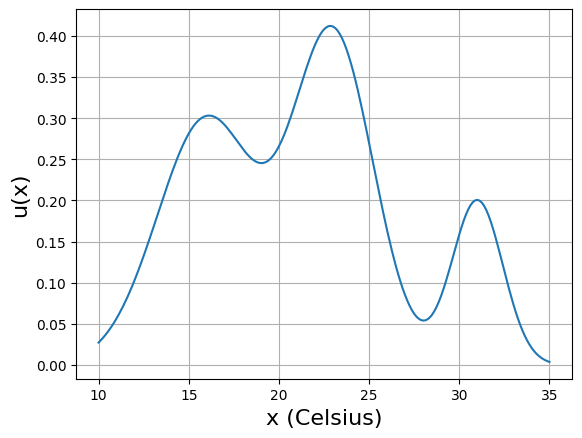

In [3]:
np.random.seed(42)
bounds=[[10,35]]
def fun(x,noise=0):
    return 0.3*np.exp(-(x-16)**2/15)+0.4*np.exp(-(x-23)**2/10)+0.2*np.exp(-(x-31)**2/4)+noise
Xpred=np.linspace(bounds[0][0],bounds[0][1],201)[:,None]

plt.plot(Xpred[:,0],fun(Xpred[:,0]))
plt.xlabel("x (Celsius)",fontsize=16)
plt.ylabel("u(x)",fontsize=16);
plt.grid()
#plt.savefig("figures/ThermalHouse.pdf")

## Consistent preference model

We generate `m` consistent preferences by selecting `n` random temperatures (objects). In other words, we assume Alice is rational - she does not make mistakes in expressing her preferences. We simulate her preferences here below based on the above utility.

In [15]:
n=251#number of objects (now it's one digit number)
X=np.linspace(bounds[0][0],bounds[0][1],n)[:,None]
#print(X) 

m=3 # Numnbers of pairs to generate
#generate preference pairs
Pairs=[]
for ii in range(m):
    np.random.seed(ii)
    i=np.random.randint(X.shape[0])
    j=np.random.randint(X.shape[0])
    if i != j:
        if fun(X[i])>fun(X[j]):
            Pairs.append([i,j])# i is preferred to j
        else:
            Pairs.append([j,i])# j is preferred to i

Pairs, indices = np.unique(Pairs, axis=0, return_index=True)#remove any duplicate pair
print("Index pairs", Pairs) 
print("temperature pairs", np.array([[X[pair[0],0], X[pair[1],0]] for pair in Pairs]))
# Note: Here, pairs are given as indices

Index pairs [[ 37 235]
 [ 47 172]
 [168  15]]
temperature pairs [[13.7 33.5]
 [14.7 27.2]
 [26.8 11.5]]


Our aim is to infer Alice's utility $u$ from the dataset of pairwise preferences above.  We will then use the
learned model to predict Alice's preference for other pairs of temperatures. We place a GP prior on $u$ and use the RBF (also called Square Exponential) kernel and estimate the utility from the preferences.

We now run the exactPreference model to learn the utility function of Alice from the preference pairs.

(array([ 1, -1,  1, -1,  1, -1]), (array([0, 0, 1, 1, 2, 2]), array([ 15, 168,  37, 235,  47, 172])))
sparse <COOrdinate sparse matrix of dtype 'int64'
	with 6 stored elements and shape (3, 250)>
  Coords	Values
  (0, 15)	1
  (0, 168)	-1
  (1, 37)	1
  (1, 235)	-1
  (2, 47)	1
  (2, 172)	-1
{'lengthscale': {'value': array([1.5]), 'range': array([[ 0.1, 20. ]]), 'transform': <utility.paramz.logexp object at 0x74330ce54620>}, 'variance': {'value': array([1.]), 'range': array([[1.    , 1.0001]]), 'transform': <utility.paramz.logexp object at 0x74330cc443e0>}}


100%|██████████| 65000/65000 [00:05<00:00, 10864.93it/s]


Sampling completed. Shape of samples: (250, 60000)


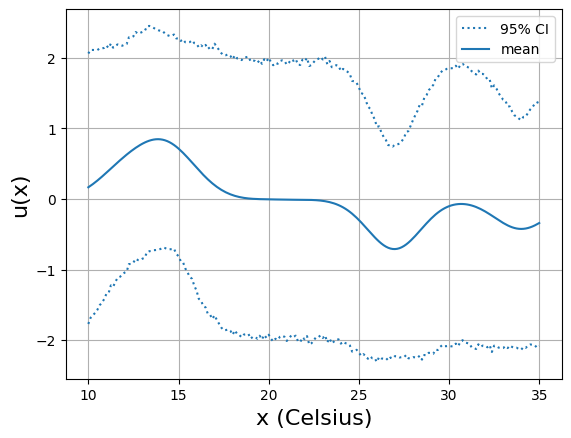

In [ ]:
# Data dictionary
data = {}
data["Pairs"] = Pairs
data["X"] = X

#kernel parameter dictionary
params={'lengthscale': {'value':1.5*np.ones(data["X"].shape[1],float), 
                        'range':np.vstack([[0.1, 20.0]]*data["X"].shape[1]),
                        'transform': paramz.logexp()},
             'variance': {'value':np.array([1.0]), 
                        'range':np.vstack([[1.0, 1.0001]]),
                        'transform': paramz.logexp()}#variance not used in exactPreference
          }

#define inference method for the hyperparameters
inf_method="laplace"
if inf_method=="advi":
    Kernel = JRBF
elif inf_method=="laplace":
    Kernel = RBF
#define preference model 
model = exactPreference(data,Kernel,params,inf_method=inf_method) # Initialize exact preference model
#compute hyperparameters
#model.optimize_hyperparams(num_restarts=2) we do not optimise the hyperparameters
print(model.params)
#sample from posterior
model.sample(nsamples=60000, tune=5000) # This does 
#predicted samples
predictions = model.predict(Xpred) # This returns (201, 60000) -> Posterior samples for 201 temperature points.


#compute the lower and upper credible intervals
credib_int = az.hdi(predictions,0.95)
#plot the latent function mean and credible interval
plt.plot(Xpred[:,0],credib_int[:,1],color='C0', linestyle=':', label='95% CI')
plt.plot(Xpred[:,0],credib_int[:,0],color='C0', linestyle=':')
plt.plot(Xpred[:,0],np.mean(predictions,axis=1), label='mean',color='C0')
plt.xlabel("x (Celsius)",fontsize=16)
plt.ylabel("u(x)",fontsize=16)
plt.legend()
plt.grid()
#plt.savefig("figures/Thermal_post_40.pdf")


(25, 60000)


/home/nanami/prefGP/notebooks/../model/exactPreference.py:129: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


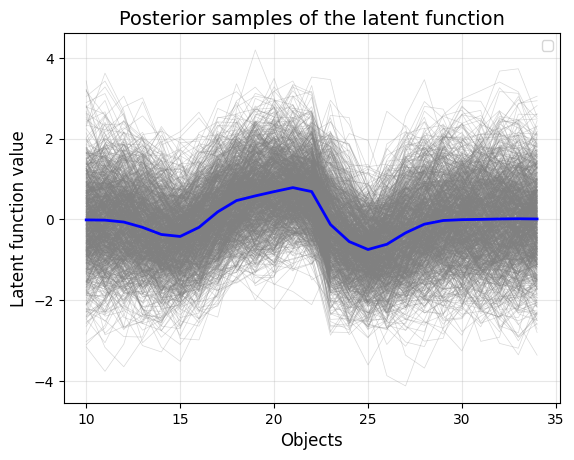

In [ ]:
# Investigate how the sampling process works
print(model.samples.shape) # (25, 60000) -> 60000 samples for 26 parameters (25 lengthscales and 1 variance)
exactPreference.visualize_sampling(model)

In [6]:
print(predictions.shape)
print(np.mean(predictions,axis=1))

print(X)

(201, 60000)
[-9.95997180e-03 -1.01266392e-02 -1.03254965e-02 -1.06084240e-02
 -1.10391697e-02 -1.16931502e-02 -1.26568139e-02 -1.40265662e-02
 -1.59072701e-02 -1.84103566e-02 -2.16515846e-02 -2.57485017e-02
 -3.08176566e-02 -3.69716103e-02 -4.43157888e-02 -5.29452108e-02
 -6.29411155e-02 -7.43675136e-02 -8.72676812e-02 -1.01660627e-01
 -1.17537577e-01 -1.34858538e-01 -1.53549038e-01 -1.73497167e-01
 -1.94551080e-01 -2.16517134e-01 -2.39158885e-01 -2.62197133e-01
 -2.85311242e-01 -3.08141886e-01 -3.30295371e-01 -3.51349584e-01
 -3.70861561e-01 -3.88376573e-01 -4.03438530e-01 -4.15601435e-01
 -4.24441504e-01 -4.29569551e-01 -4.30643150e-01 -4.27378114e-01
 -4.19558798e-01 -4.07046801e-01 -3.89787696e-01 -3.67815462e-01
 -3.41254444e-01 -3.10318690e-01 -2.75308682e-01 -2.36605522e-01
 -1.94662735e-01 -1.49995935e-01 -1.03170643e-01 -5.47886039e-02
 -5.47297840e-03  4.41471849e-02  9.34527704e-02  1.41850280e-01
  1.88786943e-01  2.33764799e-01  2.76353348e-01  3.16200319e-01
  3.53040195

In [7]:
# # Written by Nanami -- moved to another file
# from scipy.stats import norm

# def expected_improvement(x, mu, sigma, y_best):
#     x = np.atleast_2d(x)
#     print(x)
#     with np.errstate(divide='ignore'): # ignore warning of divide by sigma = 0 
#         z = (mu - y_best) / sigma
#         print(z) 
#         ei = (mu - y_best) * norm.cdf(z) + sigma * norm.pdf(z)
#         ei[sigma == 0.0] = 0.0 # expected improvement is zero if sigma is 0 
#     return ei.ravel()

# mu = np.mean(predictions, axis=1) 
# sigma = np.std(predictions, axis=1) 
# y_best = np.max(mu) # Is this correct? - I guess so.

# print(X)
# EI = expected_improvement(Xpred, mu, sigma, y_best) # This will return the expected improvement of each X point 

# # Now I find x that has max EI 
# idx_next = np.argmax(EI)
# x_next = Xpred[idx_next, 0]
# ei_max = np.max(EI)

# print("Next query point:", x_next)
# print("EI value:", ei_max)

You can see two iterations in the above output. The first one is the Laplace's approximation we run to optimise the hyperparameters of the Kernel. The second iteration is posterior sampling. We generate 65000 samples to plot "a nicely smooth" distribution. All these samples are not necessary for decision-making. We can now predict Alice's preferences for the temperature 20 versus 18. 

In [8]:
az.plot_dist(predictions[134,:]-predictions[107,:],shade=0.4,hdi_prob=1,point_estimate=None)
plt.title("")
plt.xlabel("u(20)-u(18)",fontsize=16)
plt.tight_layout()
#plt.savefig("figures/Thermal40_u20_18.pdf")


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

## Limit of Discernibility (Luce's model)

All asymmetric and negatively transitive preference relations can be thought to be originated by a utility function according to:
$$
x \succ y ~\text{ iff }~ u(x)>u(y).
$$
However, consider two objects $x,y$  whose utilities can barely be discerned by Alice, and a third object  $z$  whose utility is between that of  $x$ and $y$. In this case, Alice may either not be able to state her preference
for $z$ compared to $x,y$ (violating negative transitivity), or state a wrong preference (violating asymmetry or negative transitivity).

We consider the home-temperature  example, whose true utility function was defined previously.  We assume that two temperatures ${ x}_i,{ x}_j$ are indiscernible by Alice whenever $|u({ x}_i)-u({ x}_j)|\leq \delta$ ($\delta=0.025$ in the below example). In order to infer Alice's utility function, we consider the set of temperatures (objects) $\mathcal{X}=\{10,11,12,\dots,25\}$ and asks her preferences for $20$ pairs of temperatures. We simulate her preferences here below.

In [ ]:
n=15#number of objects
X=np.round(np.linspace(bounds[0][0],bounds[0][1],n)[:,None])


m=40 
delta =0.025 
#generate preference matrix
Pairs=[]
Pairs_ind = []
for ii in range(m):
    np.random.seed(ii)
    i=np.random.randint(X.shape[0])
    j=np.random.randint(X.shape[0])
    if i != j:
        if fun(X[i])>fun(X[j])+delta:
            Pairs.append([i,j])# i is preferred to j
        elif fun(X[j])>fun(X[i])+delta:
            Pairs.append([j,i])# j is preferred to i
        else:
            Pairs_ind.append([i,j])# j is indisc. to j
Pairs, indices = np.unique(Pairs, axis=0, return_index=True)
Pairs_ind, indices = np.unique(np.sort(Pairs_ind,axis=1), axis=0, return_index=True)
#Pairs_ind

We now run the LuceJND model to learn the utility function of Alice from the preference pairs.

In [ ]:
# Data dictionary
data = {}
data["Pairs"]  = Pairs
data["Indisc"] = Pairs_ind
data["X"] = X


#kernel parameter dictionary
params={'lengthscale': {'value':1.5*np.ones(data["X"].shape[1],float), 
                        'range':np.vstack([[0.1, 20.0]]*data["X"].shape[1]),
                        'transform': paramz.logexp()},
             'variance': {'value':np.array([1.0]), 
                        'range':np.vstack([[0.01, 100.01]]),
                        'transform': paramz.logexp()}#variance not used in exactPreference
          }

#define inference method for the hyperparameters
inf_method="laplace"
if inf_method=="advi":
    Kernel = JRBF
elif inf_method=="laplace":
    Kernel = RBF
    
#define preference model 
model = LuceJND(data,Kernel,params,inf_method=inf_method)
#compute hyperparameters
model.optimize_hyperparams(num_restarts=1,niterations=2000)#we optimise the hyperparameters
print(model.params)
#sample from posterior
model.sample(nsamples=60000, tune=5000)
#predicted samples
predictions = model.predict(Xpred)



In [ ]:
#compute the lower and upper credible intervals
credib_int = az.hdi(predictions.T,0.95)
#plot the latent function mean and credible interval
plt.plot(Xpred[:,0],credib_int[:,1],color='C0', linestyle=':', label='95% CI')
plt.plot(Xpred[:,0],credib_int[:,0],color='C0', linestyle=':')
plt.plot(Xpred[:,0],np.mean(predictions,axis=1), label='mean',color='C0')
plt.xlabel("x (Celsius)",fontsize=16)
plt.ylabel("u(x)",fontsize=16);
plt.legend()
plt.grid()
#plt.savefig("figures/Thermal_post_40_JND.pdf")

We can then predict Alice's preferences and also predicts when she cannot discerne two temperatures to the limit of discernability

In [ ]:
az.plot_density(predictions[134,:]-predictions[107,:],shade=0.4,hdi_prob=1,point_estimate=None)
plt.title("")
plt.xlabel("u(20)-u(18)",fontsize=16)
plt.tight_layout()
#plt.savefig("figures/Thermal40_u20_18_JND.pdf")


In [ ]:
# inside the JND
az.plot_density(predictions[67,:]-predictions[120,:],shade=0.4,hdi_prob=1,point_estimate=None)
plt.title("")
plt.xlabel("u(15)-u(19)",fontsize=16)
plt.tight_layout()
#plt.savefig("figures/Thermal40_u15_19_JND.pdf")

In [ ]:
az.plot_density(predictions[40,:]-predictions[107,:],shade=0.4,hdi_prob=1,point_estimate=None)
plt.title("")
plt.xlabel("u(13)-u(18)",fontsize=16)
plt.tight_layout()
#plt.savefig("figures/Thermal40_u13_18_JND.pdf")

## Probit Erroneous preference model

Luce introduced an interval of no noticeable difference to model  Alice's absence of strict preference between two indiscernible objects  $x , y$. However, there are applications where Alice is forced to express her preference between   $x , y$ even when the two objects are indiscernible.

This will result in wrong preference statements -- Alice may state   $y \succ x$ when $u(x)>u(y)$ -- overall leading to violations of asymmetry and negative transitivity. The probability of correctly stating $x \succ y$  is a function of the difference $u(x)-u(y)$, which can be  modelled by  the following likelihood:
$$
p(x \succ y|u)=\Phi\left(\frac{u(x)-u(y)}{\sigma}\right),
$$
where $\Phi(\cdot)$ is the Cumulative Distribution Function (CDF) of the 
standard Normal distribution. $\sigma>0$ is a scaling parameter, which plays a similar role to $\delta$ in Luce's model. 

In [ ]:
# plot of the Probit function
from scipy.stats import norm
deltau = np.linspace(-0.1,0.1,100)
plt.plot(deltau,norm.cdf(deltau/0.025),label="$\\sigma=0.025$")
plt.plot(deltau,norm.cdf(deltau/0.05),label="$\\sigma=0.05$")
plt.plot(deltau,norm.cdf(deltau/0.01),label="$\\sigma=0.01$")
plt.xlabel("$\\Delta_u$",fontsize=16)
plt.ylabel("probability",fontsize=16)
plt.grid()
plt.legend()
#plt.savefig("normcdf.pdf")

Note that when $\sigma \rightarrow 0$, the sigmoid approaches an indicator function. Therefore, this model converges to exact preference model. We simulate $m$ preferences using the above model and the true utility function.

In [ ]:
n=15#number of objects
X=np.round(np.linspace(bounds[0][0],bounds[0][1],n)[:,None])

sigma = 0.05# 0.05

m=40  

#generate preference pairs

Pairs=[]
for ii in range(m):
    np.random.seed(ii)
    i=np.random.randint(X.shape[0])
    j=np.random.randint(X.shape[0])
    if i != j:
        np.random.seed(ii+1)
        if np.random.rand(1)<norm.cdf((fun(X[i])-fun(X[j]))/sigma):
            Pairs.append([i,j])# i is preferred to j
        else:
            Pairs.append([j,i])# j is preferred to i
Pairs, indices = np.unique(Pairs, axis=0, return_index=True)#remove any duplicate pair

We now run the erroneousPreference model to learn the utility function of Alice from the preference pairs.

In [ ]:
# Data dictionary
data = {}
data["Pairs"]  = Pairs
data["X"] = X

# define kernel  hyperparams


#kernel parameter dictionary
params={'lengthscale': {'value':2.0*np.ones(data["X"].shape[1],float), 
                        'range':np.vstack([[0.1, 20.0]]*data["X"].shape[1]),
                        'transform': paramz.logexp()},
             'variance': {'value':np.array([5.0]), 
                        'range':np.vstack([[0.01, 100.0]]),
                        'transform': paramz.logexp()}#variance not used in exactPreference
          }
#define inference method for the hyperparameters
inf_method="advi"
if inf_method=="advi":
    Kernel = JRBF
elif inf_method=="laplace":
    Kernel = RBF
#define preference model 
model = erroneousPreference(data,Kernel,params,inf_method=inf_method)
#compute hyperparameters
model.optimize_hyperparams(num_restarts=1,niterations=5000)
print(model.params)
#sample from posterior
model.sample(nsamples=30000, tune=100)
#predicted samples
predictions = model.predict(Xpred)
#compute the lower and upper credible intervals
credib_int = az.hdi(np.array(predictions).T,0.95)


In [ ]:
#plot the latent function mean and credible interval
plt.plot(Xpred[:,0],credib_int[:,1],color='C0', linestyle=':', label='95% CI')
plt.plot(Xpred[:,0],credib_int[:,0],color='C0', linestyle=':')
plt.plot(Xpred[:,0],np.mean(predictions,axis=1), label='mean',color='C0')
plt.xlabel("x (Celsius)",fontsize=16)
plt.ylabel("u(x)",fontsize=16);
plt.legend()
plt.grid()
#plt.savefig("figures/Thermal_post_20_err_02.pdf")

We can now predict Alice's preference for 20 versus 18

In [ ]:
az.plot_density(predictions[134,:]-predictions[107,:],shade=0.4,hdi_prob=1,point_estimate=None)
plt.title("")
plt.xlabel("u(20)-u(18)",fontsize=16)
plt.tight_layout()
#plt.savefig("figures/Thermal20_u20_18_err_02.pdf")

In [ ]:
az.plot_density(predictions[67,:]-predictions[120,:],shade=0.4,hdi_prob=1,point_estimate=None)
plt.title("")
plt.xlabel("u(15)-u(19)",fontsize=16)
plt.tight_layout()
#plt.savefig("figures/Thermal20_u15_19_err_005.pdf")

## Gaussian Noise 

Another potential issue arises in the case the observed utility function differs from the true utility function (due to disturbances, measurement errors).  In this situation, Alice states $x \succ y$ if the observed  utility of $x$ is greater than the observed utility of $y$, i.e.,\ $o(x)>o(y)$.
The observation error is commonly assumed to be additive Gaussian, that is  $o(x)=u(x)+v_x$ and $o(y)=u(y)+v_y$, where $v_x,v_y$ are two independent and Gaussian distributed variables with zero mean and variance $\sigma^2_v$. Due to the observation error, preferences may violate asymmetry or negative transitivity or both. 

We now generate $m$ noisy preferences.

In [ ]:
n=15#number of objects
np.random.seed(2)
X=(np.linspace(bounds[0][0],bounds[0][1],n)[:,None])
sigma=0.1
noise = sigma*np.random.randn(n)

m=120

#generate preference matrix
Pairs=[]
for ii in range(m):
    i=np.random.randint(X.shape[0])
    j=np.random.randint(X.shape[0])
    if i != j:
        if fun(X[i],noise[i])>fun(X[j],noise[j]):
            Pairs.append([i,j])# i is preferred to j
        elif fun(X[j],noise[j])>fun(X[i],noise[i]):
            Pairs.append([j,i])# j is preferred to i
Pairs, indices = np.unique(Pairs, axis=0, return_index=True)

We run the gaussianNoisePreference model to learn the utility function of Alice from the preference pairs. Note that, the preferences are not indpendent anymore because of the common noise. gaussianNoisePreference accounts for this dependence in the likelihood, by using augementad variables.

In [ ]:
# data dictionary
data = {}
data["Pairs"] = Pairs
data["X"] = X



# kernel parameter dictionary
params={'lengthscale': {'value':1.0*np.ones(data["X"].shape[1],float), 
                        'range':np.vstack([[0.1, 3.0]]*data["X"].shape[1]),
                        'transform': paramz.logexp()},
          'variance': {'value':np.array([1.0]), 
                        'range':np.vstack([[0.001, 50]]),
                        'transform': paramz.logexp()},
             'noise_variance': {'value':np.array([0.5]), 
                        'range':np.vstack([[0.001, 10.001]]),
                        'transform': paramz.logexp()}#variance not used in exactPreference
          }

inf_method="laplace"
if inf_method=="advi":
    Kernel = JRBF
elif inf_method=="laplace":
    Kernel = RBF
    
# define preference model 
model = gaussianNoisePreference(data,Kernel,params,inf_method=inf_method)
# compute hyperparameters
model.optimize_hyperparams(num_restarts=6,niterations=25000)
print(model.params)
# sample from posterior
model.sample(nsamples=30000, tune=5000)
# predicted samples
predictions = model.predict(Xpred)
# compute the lower and upper credible intervals
credib_int = az.hdi(predictions.T,0.95)
# plot the latent function mean and credible interval
plt.plot(Xpred[:,0],fun(Xpred[:,0]), label='true',color='C1')
plt.plot(Xpred[:,0],credib_int[:,1],color='C2', linestyle=':')
plt.plot(Xpred[:,0],credib_int[:,0],color='C2', linestyle=':')
plt.plot(Xpred[:,0],np.mean(predictions,axis=1), label='mean',color='C2')
plt.xlabel("x",fontsize=16)
plt.ylabel("f(x)",fontsize=16)
plt.legend()

In [ ]:
#plot the latent function mean and credible interval
plt.plot(Xpred[:,0],credib_int[:,1],color='C0', linestyle=':', label='95% CI')
plt.plot(Xpred[:,0],credib_int[:,0],color='C0', linestyle=':')
plt.plot(Xpred[:,0],np.mean(predictions,axis=1), label='mean',color='C0')
plt.xlabel("x (Celsius)",fontsize=16)
plt.ylabel("u(x)",fontsize=16);
plt.legend()
plt.grid()
#plt.savefig("figures/Thermal_gaussiannoise.pdf")

   We can compute the posterior utility using the `Probit Erroneous preference model` which ignores
the common noise and, therefore, assumes independence between the preferences pairs.

In [ ]:
# Data dictionary
data = {}
data["Pairs"]  = Pairs
data["X"] = X

# define kernel and hyperparams
Kernel = RBF

#kernel parameter dictionary
params={'lengthscale': {'value':1.0*np.ones(data["X"].shape[1],float), 
                        'range':np.vstack([[0.1, 3.0]]*data["X"].shape[1]),
                        'transform': paramz.logexp()},
             'variance': {'value':np.array([1.0]), 
                        'range':np.vstack([[0.01, 100.0]]),
                        'transform': paramz.logexp()}#variance not used in exactPreference
          }


#define preference model 
model = erroneousPreference(data,Kernel,params)
#compute hyperparameters
model.optimize_hyperparams(num_restarts=3)
print(model.params)
#sample from posterior
model.sample(nsamples=60000, tune=5000)
#predicted samples
predictions = model.predict(Xpred)
#compute the lower and upper credible intervals
credib_int = az.hdi(predictions.T,0.95)

We can see that this model wrongly fits the noise and produces an incorrect estimate of the function. 

In [ ]:
#plot the latent function mean and credible interval
plt.plot(Xpred[:,0],credib_int[:,1],color='C0', linestyle=':', label='95% CI')
plt.plot(Xpred[:,0],credib_int[:,0],color='C0', linestyle=':')
plt.plot(Xpred[:,0],np.mean(predictions,axis=1), label='mean',color='C0')
plt.xlabel("x (Celsius)",fontsize=16)
plt.ylabel("u(x)",fontsize=16);
plt.legend()
plt.grid()
#plt.savefig("Thermal_gaussiannoise_erroneous.pdf")